# S09 – Обучение НС и оптимизация (PyTorch): Schedulers и Gradient Clipping

В этом ноутбуке пробуем **управлять процессом обучения** нейросети, а не подбирать магическую архитектуру.

Фокус:
- **Learning rate schedules** (как и зачем менять LR по ходу обучения),
- **правильное место `scheduler.step()`** (типовая ошибка),
- **gradient clipping** как инженерная страховка от нестабильного обучения.

## 0. План

К концу ноутбука студент надо уметь:

1) Подключить scheduler и корректно обновлять LR:
   - `StepLR` / `CosineAnnealingLR` (шаг по эпохам),
   - `ReduceLROnPlateau` (шаг по метрике валидации).

2) По графикам и логам понимать:
   - что LR уменьшается так, как вы ожидаете,
   - как schedule влияет на сходимость и качество.

3) Понять смысл gradient clipping:
   - что такое "норма градиента",
   - как клиппинг ограничивает её,
   - почему это полезно как предохранитель (особенно на более сложных моделях).

## 1. Импорты и общие настройки

Сразу фиксируем seed и выбираем `device`.

Также вводим параметр **FAST_MODE**: по умолчанию мы берём небольшой поднабор данных и меньше эпох, чтобы всё выполнялось быстро даже на CPU. Если хотите – переключите `FAST_MODE=False`.

In [1]:

import os
import math
import random
from dataclasses import dataclass, asdict
from typing import Dict, Any, Tuple, Optional, List

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Для Windows: num_workers=0 по умолчанию (чтобы избежать проблем с multiprocessing)
DEFAULT_NUM_WORKERS = 0

# Быстрый режим (рекомендуется для семинара/проверки)
FAST_MODE = True

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def maybe_subset(ds, max_items: Optional[int], seed: int = 42):
    if max_items is None:
        return ds
    n = len(ds)
    if max_items >= n:
        return ds
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=max_items, replace=False)
    return Subset(ds, idx.tolist())

set_seed(42)
device = get_device()
device

device(type='cuda')

## 2. Данные

По умолчанию пытаемся загрузить **KMNIST** из `torchvision`.
Если `torchvision` недоступен – fallback на `sklearn.load_digits` (8×8 картинки).

Используем MLP, поэтому картинки превращаем в вектор внутри модели (`Flatten`).

В FAST_MODE берём небольшой поднабор данных (чтобы всё крутилось быстро).

In [2]:

def load_dataset(name: str = "KMNIST", fast_mode: bool = True):
    """Загружает датасет через torchvision. Если torchvision недоступен – fallback на sklearn digits."""
    try:
        import torchvision
        from torchvision import transforms
        from torchvision.datasets import KMNIST, EMNIST, CIFAR10

        # лимиты под FAST_MODE
        max_train = 12000 if fast_mode else None
        max_test  = 3000 if fast_mode else None

        if name.upper() == "KMNIST":
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])
            ds_train = KMNIST(root="./data", train=True, download=True, transform=transform)
            ds_test  = KMNIST(root="./data", train=False, download=True, transform=transform)
            ds_train = maybe_subset(ds_train, max_train, seed=42)
            ds_test  = maybe_subset(ds_test, max_test, seed=43)
            input_shape = (1, 28, 28)
            num_classes = 10
            return ds_train, ds_test, input_shape, num_classes, f"{name} (torchvision)"

        if name.upper() == "EMNIST_BALANCED":
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])
            ds_train = EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)
            ds_test  = EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)
            ds_train = maybe_subset(ds_train, max_train, seed=42)
            ds_test  = maybe_subset(ds_test, max_test, seed=43)
            input_shape = (1, 28, 28)
            num_classes = len(getattr(ds_train, "dataset", ds_train).classes)  # учитываем Subset
            return ds_train, ds_test, input_shape, num_classes, f"{name} (torchvision)"

        if name.upper() == "CIFAR10":
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
            ])
            ds_train = CIFAR10(root="./data", train=True, download=True, transform=transform)
            ds_test  = CIFAR10(root="./data", train=False, download=True, transform=transform)
            ds_train = maybe_subset(ds_train, max_train, seed=42)
            ds_test  = maybe_subset(ds_test, max_test, seed=43)
            input_shape = (3, 32, 32)
            num_classes = 10
            return ds_train, ds_test, input_shape, num_classes, f"{name} (torchvision)"

        raise ValueError(f"Unknown dataset name: {name}")

    except Exception as e:
        print("torchvision недоступен или возникла ошибка загрузки. Fallback на sklearn.load_digits.")
        print("Причина:", repr(e))
        from sklearn.datasets import load_digits
        digits = load_digits()
        X = digits.images.astype(np.float32) / 16.0  # [0..1]
        y = digits.target.astype(np.int64)

        class DigitsDataset(torch.utils.data.Dataset):
            def __init__(self, X, y):
                self.X = torch.tensor(X).unsqueeze(1)  # (N,1,8,8)
                self.y = torch.tensor(y)
            def __len__(self): return self.X.shape[0]
            def __getitem__(self, idx): return self.X[idx], self.y[idx]

        ds_full = DigitsDataset(X, y)
        # split: 80/20
        n = len(ds_full)
        n_train = int(0.8 * n)
        n_test = n - n_train
        ds_train, ds_test = random_split(ds_full, [n_train, n_test], generator=torch.Generator().manual_seed(42))

        if fast_mode:
            ds_train = maybe_subset(ds_train, 1200, seed=42)
            ds_test  = maybe_subset(ds_test, 400, seed=43)

        input_shape = (1, 8, 8)
        num_classes = 10
        return ds_train, ds_test, input_shape, num_classes, "sklearn.load_digits (fallback)"

ds_train_full, ds_test, input_shape, num_classes, ds_name = load_dataset("EMNIST_BALANCED", fast_mode=FAST_MODE)
ds_name, input_shape, num_classes, len(ds_train_full), len(ds_test)

100%|██████████| 562M/562M [00:03<00:00, 145MB/s] 


('EMNIST_BALANCED (torchvision)', (1, 28, 28), 47, 12000, 3000)

### Разбиение train/val и DataLoader

Делаем валидирующую выборку из train-части, чтобы:
- выбирать гиперпараметры (и “лучший прогон”) **по val**,
- трогать test только в конце (один раз, на лучшей модели).

In [3]:

def make_loaders(ds_train_full, ds_test, batch_size: int = 128, val_ratio: float = 0.2, seed: int = 42):
    n_total = len(ds_train_full)
    n_val = max(1, int(n_total * val_ratio))
    n_train = n_total - n_val

    gen = torch.Generator().manual_seed(seed)
    ds_train, ds_val = random_split(ds_train_full, [n_train, n_val], generator=gen)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full, ds_test, batch_size=128)

# sanity-check
x, y = next(iter(train_loader))
x.shape, y.shape, x.min().item(), x.max().item()

(torch.Size([128, 1, 28, 28]), torch.Size([128]), -1.0, 1.0)

## 3. Модель: MLP (полносвязная сеть)

Не меняем тип модели9. Здесь важно другое: **как мы управляем обучением**.

Ниже – MLP-конструктор:
- можно менять глубину/ширину,
- можно включать/выключать BatchNorm и Dropout.

In [4]:

class MLP(nn.Module):
    def __init__(
        self,
        input_shape: Tuple[int, int, int],
        num_classes: int,
        hidden_sizes: List[int] = [256, 128],
        activation: str = "relu",
        use_batchnorm: bool = False,
        dropout: float = 0.0,
    ):
        super().__init__()
        c, h, w = input_shape
        in_features = c * h * w

        act_layer = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "gelu": nn.GELU,
        }.get(activation.lower(), nn.ReLU)

        layers: List[nn.Module] = [nn.Flatten()]

        prev = in_features
        for hs in hidden_sizes:
            layers.append(nn.Linear(prev, hs))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hs))
            layers.append(act_layer())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hs

        layers.append(nn.Linear(prev, num_classes))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 4) Train/Eval цикл, логирование LR и нормы градиента

Сейчас важно:
- корректный `train()/eval()`;
- понимать, **какой LR реально используется** (логируем LR по эпохам);
- уметь включать **gradient clipping** и видеть его эффект (логируем `grad_norm`).

In [5]:

def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def grad_global_norm(parameters) -> float:
    total_norm_sq = 0.0
    for p in parameters:
        if p.grad is None:
            continue
        param_norm = p.grad.data.norm(2).item()
        total_norm_sq += param_norm ** 2
    return math.sqrt(total_norm_sq)

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    max_grad_norm: Optional[float] = None,
    log_grad_norm: bool = False,
):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    grad_norms_before = []
    grad_norms_after = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        # иногда на очень агрессивных настройках бывает NaN – делаем мягкую защиту
        if not torch.isfinite(loss):
            continue

        loss.backward()

        if log_grad_norm:
            gn_before = grad_global_norm(model.parameters())
            grad_norms_before.append(gn_before)

        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            if log_grad_norm:
                gn_after = grad_global_norm(model.parameters())
                grad_norms_after.append(gn_after)

        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs

    avg_loss = total_loss / max(1, n)
    avg_acc = total_acc / max(1, n)

    out = {"loss": float(avg_loss), "acc": float(avg_acc)}
    if log_grad_norm:
        out["grad_norm_before_mean"] = float(np.mean(grad_norms_before)) if grad_norms_before else None
        if max_grad_norm is not None:
            out["grad_norm_after_mean"] = float(np.mean(grad_norms_after)) if grad_norms_after else None
    return out

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            continue
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs
    return {"loss": float(total_loss / max(1, n)), "acc": float(total_acc / max(1, n))}

def plot_history(history: Dict[str, List[float]], title: str = ""):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(list(epochs), history["train_loss"], label="train_loss")
    plt.plot(list(epochs), history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title or "Loss curves")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(list(epochs), history["train_acc"], label="train_acc")
    plt.plot(list(epochs), history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title or "Accuracy curves")
    plt.legend()
    plt.show()

## 5. Scheduler: правильные варианты и типовая ошибка

Есть два принципиально разных типа scheduler:

1) **Шаг по эпохам** (StepLR, CosineAnnealingLR и т.п.)  
   Вызываем `scheduler.step()` **после эпохи**.

2) **Шаг по метрике валидации** (`ReduceLROnPlateau`)  
   Вызываем `scheduler.step(val_loss)` **после валидации**.

Типовая ошибка: вызвать `scheduler.step()` *внутри батчевого цикла*, и LR схлопнется слишком быстро.

In [6]:

@dataclass
class RunConfig:
    name: str
    hidden_sizes: List[int] = None
    activation: str = "relu"
    use_batchnorm: bool = False
    dropout: float = 0.0

    optimizer: str = "adam"          # "adam" | "sgd"
    lr: float = 1e-3
    weight_decay: float = 0.0

    epochs: int = 8 if FAST_MODE else 15
    batch_size: int = 128

    scheduler: str = "none"          # "none" | "step" | "cosine" | "plateau"
    step_size: int = 3               # StepLR
    gamma: float = 0.5               # StepLR
    t_max: int = 8                   # CosineAnnealingLR
    plateau_patience: int = 2        # ReduceLROnPlateau
    plateau_factor: float = 0.5      # ReduceLROnPlateau

    max_grad_norm: Optional[float] = None  # clipping
    log_grad_norm: bool = False

    seed: int = 42
    dataset: str = ds_name

def make_optimizer(model: nn.Module, cfg: RunConfig):
    if cfg.optimizer.lower() == "adam":
        return torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    if cfg.optimizer.lower() == "sgd":
        return torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=0.9, weight_decay=cfg.weight_decay)
    raise ValueError(f"Unknown optimizer: {cfg.optimizer}")

def make_scheduler(optimizer: torch.optim.Optimizer, cfg: RunConfig):
    s = cfg.scheduler.lower()
    if s == "none":
        return None
    if s == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, step_size=cfg.step_size, gamma=cfg.gamma)
    if s == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.t_max)
    if s == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", patience=cfg.plateau_patience, factor=cfg.plateau_factor
        )
    raise ValueError(f"Unknown scheduler: {cfg.scheduler}")

def current_lr(optimizer: torch.optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(cfg: RunConfig, ds_train_full, ds_test, input_shape, num_classes, device: torch.device):
    set_seed(cfg.seed)
    train_loader, val_loader, test_loader = make_loaders(ds_train_full, ds_test, batch_size=cfg.batch_size, val_ratio=0.2, seed=cfg.seed)

    model = MLP(
        input_shape=input_shape,
        num_classes=num_classes,
        hidden_sizes=cfg.hidden_sizes or [256, 128],
        activation=cfg.activation,
        use_batchnorm=cfg.use_batchnorm,
        dropout=cfg.dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, cfg)
    scheduler = make_scheduler(optimizer, cfg)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "lr": [],
        "grad_norm_before": [],
        "grad_norm_after": [],
    }

    best_val_acc = -1.0
    best_state = None
    best_epoch = -1

    for epoch in range(1, cfg.epochs + 1):
        train_out = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            max_grad_norm=cfg.max_grad_norm,
            log_grad_norm=cfg.log_grad_norm,
        )
        val_out = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_out["loss"])
        history["train_acc"].append(train_out["acc"])
        history["val_loss"].append(val_out["loss"])
        history["val_acc"].append(val_out["acc"])
        history["lr"].append(current_lr(optimizer))

        if cfg.log_grad_norm:
            history["grad_norm_before"].append(train_out.get("grad_norm_before_mean"))
            history["grad_norm_after"].append(train_out.get("grad_norm_after_mean"))

        if val_out["acc"] > best_val_acc:
            best_val_acc = val_out["acc"]
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # ВАЖНО: где делаем scheduler.step()
        if scheduler is not None:
            if cfg.scheduler.lower() == "plateau":
                scheduler.step(val_out["loss"])  # шаг по метрике
            else:
                scheduler.step()                 # шаг по эпохам

    # финальная оценка на test (один раз, на best_state)
    if best_state is not None:
        model.load_state_dict(best_state)
    test_out = evaluate(model, test_loader, criterion, device)

    return {
        "cfg": asdict(cfg),
        "best_val_acc": float(best_val_acc),
        "best_epoch": int(best_epoch),
        "test_acc": float(test_out["acc"]),
        "test_loss": float(test_out["loss"]),
        "history": history,
        "model_state_dict": best_state,
    }

### 5.1 Демонстрация типовой ошибки: `StepLR.step()` в батчевом цикле

Специально покажем **плохой** вариант: если делать `scheduler.step()` *на каждом батче*, LR будет падать слишком быстро.

Сделаем очень короткий запуск и посмотрим, как меняется LR.

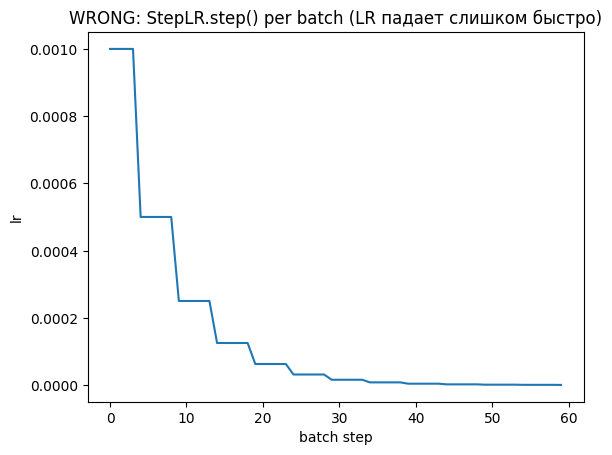

LR start: 0.001 LR end: 2.44140625e-07 steps: 60


In [7]:

def wrong_step_demo(ds_train_full, ds_test, input_shape, num_classes, device, max_batches: int = 60):
    cfg = RunConfig(
        name="WRONG_StepLR_per_batch",
        hidden_sizes=[128, 64],
        optimizer="adam",
        lr=1e-3,
        epochs=1,
        scheduler="step",
        step_size=5,
        gamma=0.5,
        batch_size=128,
    )
    set_seed(cfg.seed)
    train_loader, _, _ = make_loaders(ds_train_full, ds_test, batch_size=cfg.batch_size, val_ratio=0.2, seed=cfg.seed)

    model = MLP(input_shape, num_classes, cfg.hidden_sizes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model, cfg)
    scheduler = make_scheduler(optimizer, cfg)

    lrs = []
    model.train()
    for i, (x, y) in enumerate(train_loader):
        if i >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(x), y)
        if not torch.isfinite(loss):
            continue
        loss.backward()
        optimizer.step()

        # НЕПРАВИЛЬНО: StepLR по батчам
        scheduler.step()
        lrs.append(current_lr(optimizer))
    return lrs

lrs_wrong = wrong_step_demo(ds_train_full, ds_test, input_shape, num_classes, device)
plt.figure()
plt.plot(lrs_wrong)
plt.xlabel("batch step")
plt.ylabel("lr")
plt.title("WRONG: StepLR.step() per batch (LR падает слишком быстро)")
plt.show()

if lrs_wrong:
    print("LR start:", lrs_wrong[0], "LR end:", lrs_wrong[-1], "steps:", len(lrs_wrong))

## 6. Эксперимент: сравниваем scheduler'ы

Делаем 3 запуска на одинаковой модели:

- E0: без scheduler (фиксированный LR)
- E1: StepLR (шаг по эпохам)
- E2: ReduceLROnPlateau (шаг по val_loss)

Смотрим:
- кривые train/val,
- как меняется LR по эпохам,
- итоговое качество на test (по лучшему состоянию по val_acc).

In [8]:

base_cfg = RunConfig(
    name="E0_no_scheduler",
    hidden_sizes=[256, 128],
    activation="relu",
    use_batchnorm=False,
    dropout=0.0,
    optimizer="adam",
    lr=1e-3,
    weight_decay=0.0,
    epochs=8 if FAST_MODE else 15,
    batch_size=128,
    scheduler="none",
)

cfg_step = RunConfig(**{**asdict(base_cfg), "name": "E1_StepLR", "scheduler": "step", "step_size": 3, "gamma": 0.5})
cfg_plateau = RunConfig(**{**asdict(base_cfg), "name": "E2_ReduceLROnPlateau", "scheduler": "plateau", "plateau_patience": 2, "plateau_factor": 0.5})

runs = []
for cfg in [base_cfg, cfg_step, cfg_plateau]:
    print(f"Running: {cfg.name} | scheduler={cfg.scheduler} | lr={cfg.lr}")
    out = fit(cfg, ds_train_full, ds_test, input_shape, num_classes, device)
    runs.append(out)

summary = []
for r in runs:
    summary.append({
        "run": r["cfg"]["name"],
        "scheduler": r["cfg"]["scheduler"],
        "best_val_acc": r["best_val_acc"],
        "best_epoch": r["best_epoch"],
        "test_acc": r["test_acc"],
    })
summary

Running: E0_no_scheduler | scheduler=none | lr=0.001
Running: E1_StepLR | scheduler=step | lr=0.001
Running: E2_ReduceLROnPlateau | scheduler=plateau | lr=0.001


[{'run': 'E0_no_scheduler',
  'scheduler': 'none',
  'best_val_acc': 0.7195833349227905,
  'best_epoch': 8,
  'test_acc': 0.7123333339691162},
 {'run': 'E1_StepLR',
  'scheduler': 'step',
  'best_val_acc': 0.6916666666666667,
  'best_epoch': 8,
  'test_acc': 0.6886666666666666},
 {'run': 'E2_ReduceLROnPlateau',
  'scheduler': 'plateau',
  'best_val_acc': 0.7195833349227905,
  'best_epoch': 8,
  'test_acc': 0.7123333339691162}]

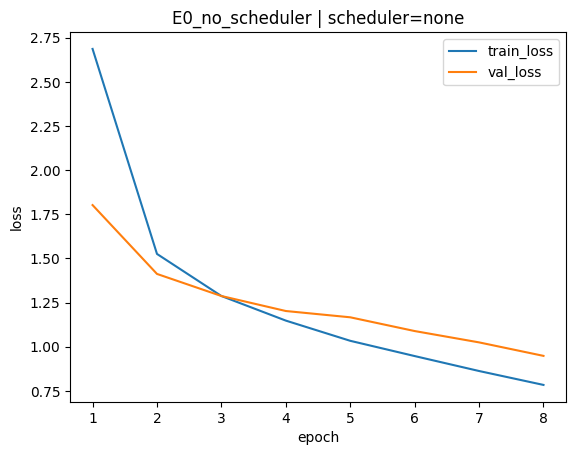

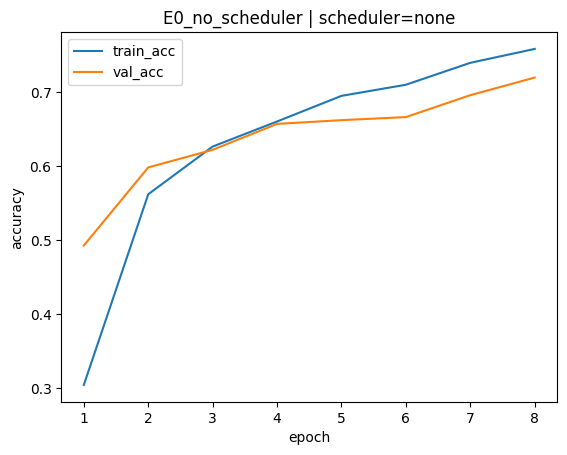

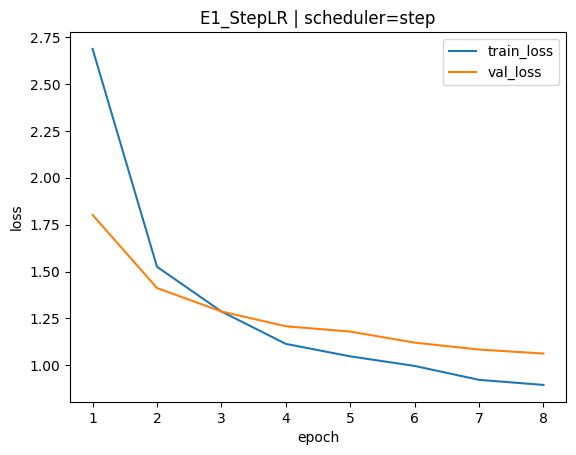

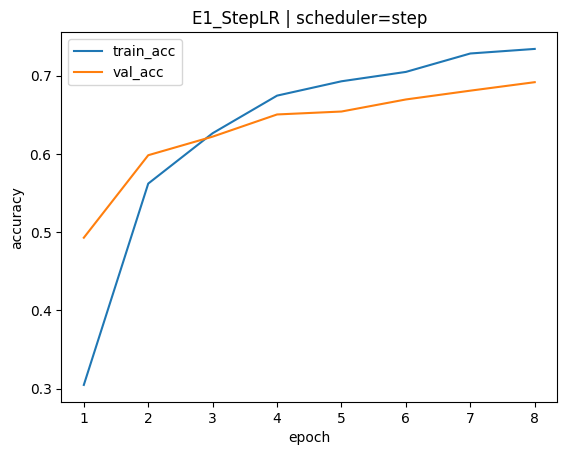

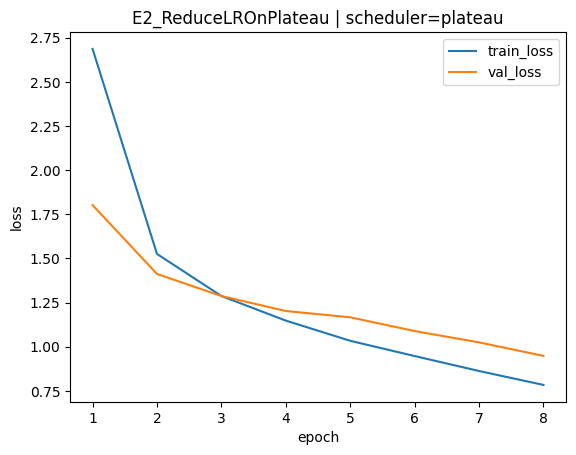

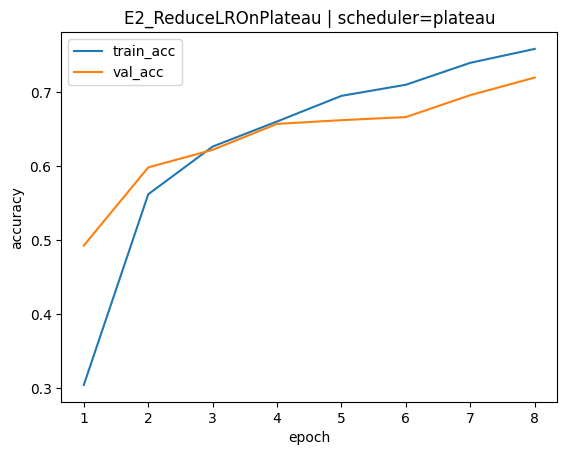

In [9]:

for r in runs:
    title = f'{r["cfg"]["name"]} | scheduler={r["cfg"]["scheduler"]}'
    plot_history(r["history"], title=title)

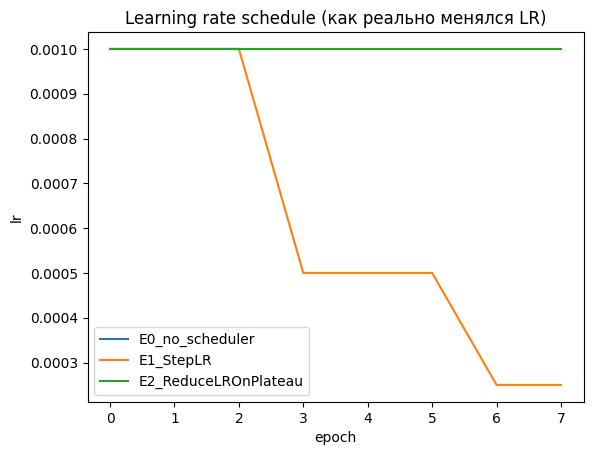

In [10]:

plt.figure()
for r in runs:
    plt.plot(r["history"]["lr"], label=r["cfg"]["name"])
plt.xlabel("epoch")
plt.ylabel("lr")
plt.title("Learning rate schedule (как реально менялся LR)")
plt.legend()
plt.show()

## 7. Gradient clipping: что это и зачем

Клиппинг – это ограничение нормы градиента: если градиент взрывается, то не даём ему стать слишком большим.

Важно:
- клиппинг – это **предохранитель стабильности**;
- эффект полезнее всего заметен на "нервных" конфигурациях (глубже модель, выше LR и т.п.).

Намеренно сделаем более агрессивный режим и сравним:
- без клиппинга,
- с клиппингом (`max_grad_norm=1.0`).

Логируем среднюю норму градиента по эпохе (до/после клиппинга).

Running: C0_unstable_no_clipping | lr=0.8 | clipping=None
Running: C1_unstable_with_clipping | lr=0.8 | clipping=1.0


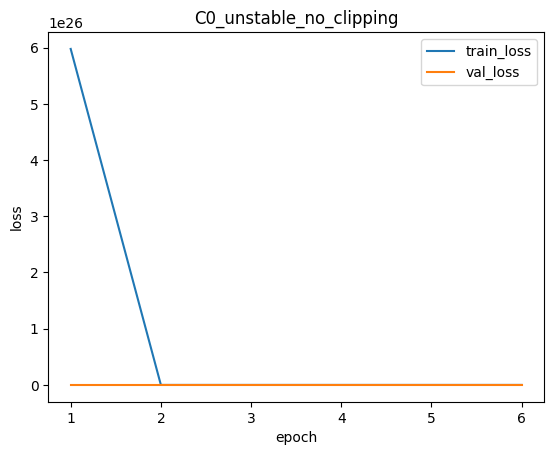

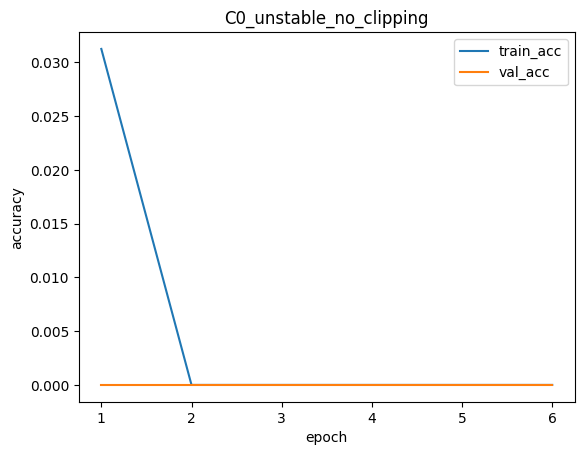

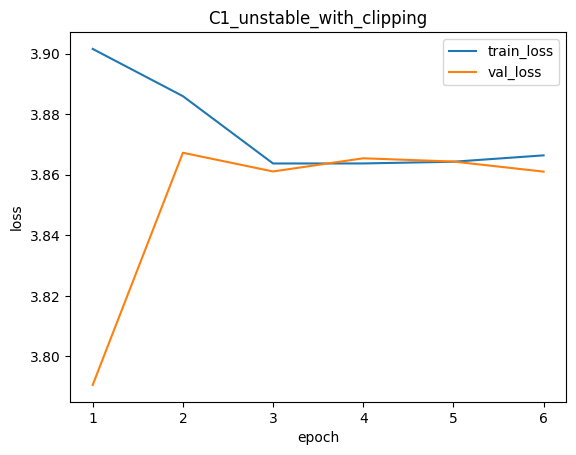

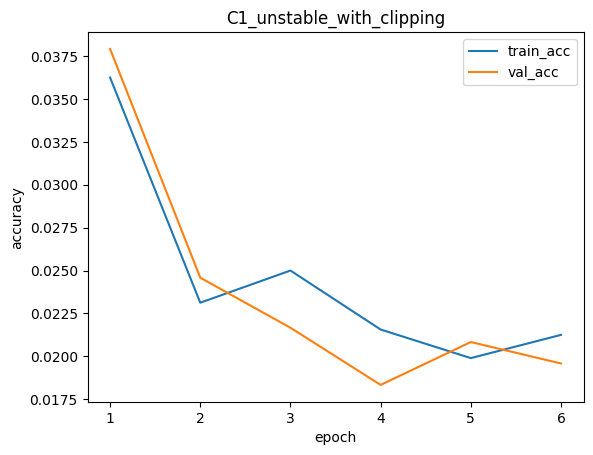

In [11]:

unstable_base = RunConfig(
    name="C0_unstable_no_clipping",
    hidden_sizes=[512, 256, 256, 128, 128],
    activation="relu",
    use_batchnorm=False,
    dropout=0.0,
    optimizer="sgd",
    lr=0.8 if FAST_MODE else 0.5,   # агрессивно; на некоторых средах можно уменьшить
    weight_decay=0.0,
    epochs=6 if FAST_MODE else 10,
    batch_size=128,
    scheduler="none",
    log_grad_norm=True,
    max_grad_norm=None,
)

unstable_clip = RunConfig(**{**asdict(unstable_base), "name": "C1_unstable_with_clipping", "max_grad_norm": 1.0})

clip_runs = []
for cfg in [unstable_base, unstable_clip]:
    print(f"Running: {cfg.name} | lr={cfg.lr} | clipping={cfg.max_grad_norm}")
    out = fit(cfg, ds_train_full, ds_test, input_shape, num_classes, device)
    clip_runs.append(out)

for r in clip_runs:
    plot_history(r["history"], title=r["cfg"]["name"])

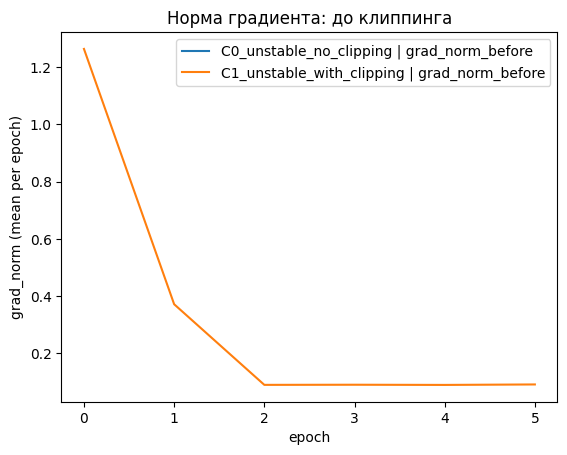

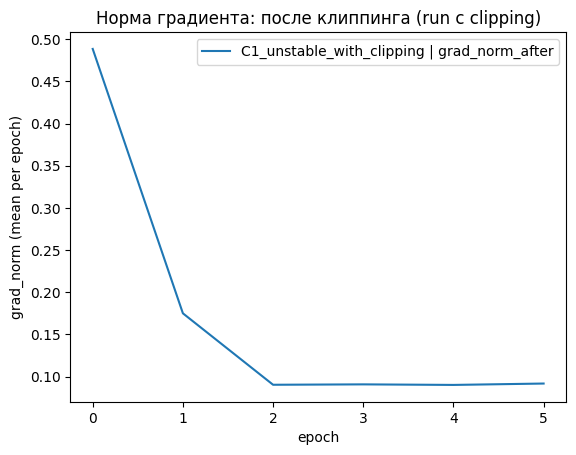

In [12]:

plt.figure()
for r in clip_runs:
    gn_before = r["history"]["grad_norm_before"]
    if gn_before and any(v is not None for v in gn_before):
        plt.plot(gn_before, label=f'{r["cfg"]["name"]} | grad_norm_before')
plt.xlabel("epoch")
plt.ylabel("grad_norm (mean per epoch)")
plt.title("Норма градиента: до клиппинга")
plt.legend()
plt.show()

plt.figure()
for r in clip_runs:
    gn_after = r["history"]["grad_norm_after"]
    if gn_after and any(v is not None for v in gn_after):
        plt.plot(gn_after, label=f'{r["cfg"]["name"]} | grad_norm_after')
plt.xlabel("epoch")
plt.ylabel("grad_norm (mean per epoch)")
plt.title("Норма градиента: после клиппинга (run с clipping)")
plt.legend()
plt.show()

## 8. Мини-резюме "боевого" подхода

Инженерный набор привычек:

- логировать LR (иначе вы не знаете, что реально происходит),
- смотреть train/val кривые (диагноз по симптомам),
- выбирать scheduler под задачу:
  - "по эпохам" или "по метрике",
- держать clipping как страховку (особенно если видите нестабильность).

## 9. Выводы

1) Scheduler'ы бывают разных типов:
   - `StepLR/Cosine` – шаг по эпохам,
   - `ReduceLROnPlateau` – шаг по метрике валидации.

2) `scheduler.step()` нужно вызывать **в правильном месте**:
   - обычно после эпохи,
   - или после валидации (если Plateau).

3) Gradient clipping – полезный предохранитель:
   - ограничивает взрыв градиента,
   - повышает стабильность обучения на “нервных” конфигурациях.

4) Управление обучением = **наблюдаем сигналы (кривые, LR, градиенты) и применяем правильные рычаги**.